In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

In [5]:
import os

folder_path = r"C:\Users\hp\Documents\Oasis Infobyte Tasks or Projects Documents\Task 4\Task 4 Documents\ipynb extra files"

os.listdir(folder_path)

['Sentiment_Analysis.ipynb', 'test.csv']

In [7]:
file_path = r"C:\Users\hp\Documents\Oasis Infobyte Tasks or Projects Documents\Task 4\Task 4 Documents\ipynb extra files\train.csv"

df = pd.read_csv(file_path, encoding="latin-1")

In [8]:
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on the releases we already bought","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 27481
Number of columns: 10


In [10]:
print("Columns:")
print(df.columns.tolist())

Columns:
['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB


In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
print("Sentiment classes:")
print(df["sentiment"].unique())

Sentiment classes:
['neutral' 'negative' 'positive']


In [15]:
sentiment_counts = df["sentiment"].value_counts()

print("Sentiment distribution:")
print(sentiment_counts)

Sentiment distribution:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


In [16]:
print("Number of missing text values:", df["text"].isnull().sum())
print("\nExample texts:")
print(df["text"].dropna().head())

Number of missing text values: 1

Example texts:
0                                            I`d have responded, if I were going
1                                  Sooo SAD I will miss you here in San Diego!!!
2                                                      my boss is bullying me...
3                                                 what interview! leave me alone
4     Sons of ****, why couldn`t they put them on the releases we already bought
Name: text, dtype: object


In [17]:
df.describe(include="all")

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
count,27481,27480,27480,27481,27481,27481,27481,2.748100e+04,2.748100e+04,27481.000000
unique,27481,27480,22430,3,3,6,195,NaN,NaN,NaN
top,cb774db0d1,"I`d have responded, if I were going",good,neutral,morning,0-20,Afghanistan,NaN,NaN,NaN
freq,1,1,199,11118,9161,4581,149,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.018497e+07,6.621730e+05,357.686583
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.504946e+08,1.807425e+06,2013.750702
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.010000e+02,0.000000e+00,2.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.968001e+06,2.281000e+04,35.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.655535e+06,1.118900e+05,89.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.843594e+07,5.279700e+05,214.000000


# Sentiment Analysis

## 1. Sentiment Distribution

Before building the machine learning models, we will examine the distribution of sentiment classes in the dataset. This helps us understand how the tweets are distributed among the three sentiment categories: positive, negative, and neutral.


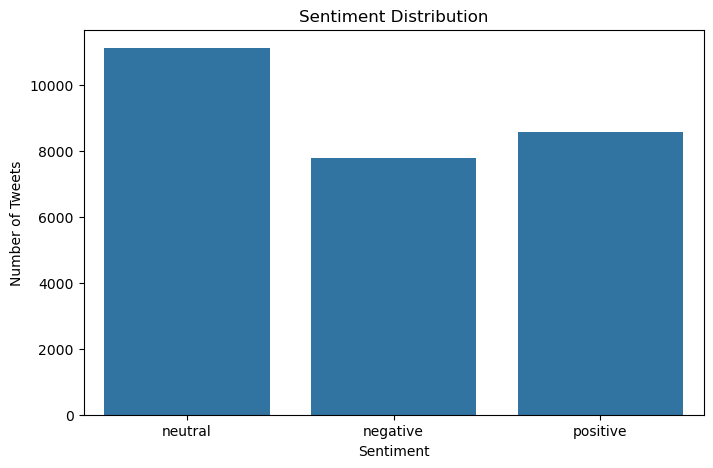

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

### Sentiment Distribution Percentages

The percentage distribution of each sentiment class is calculated to better understand the proportion of positive, negative, and neutral tweets in the dataset.


In [19]:
sentiment_percentage = df["sentiment"].value_counts(normalize=True) * 100

print("Sentiment Distribution (%):")
print(sentiment_percentage.round(2))

Sentiment Distribution (%):
sentiment
neutral     40.46
positive    31.23
negative    28.31
Name: proportion, dtype: float64


## 2. Handling Missing Text Values

The dataset contains one missing value in the `text` column. Since this column contains the text that will be used for sentiment analysis, the record with the missing text value will be removed before proceeding with text preprocessing and model training.


In [20]:
df = df.dropna(subset=["text"]).copy()

In [21]:
print("Missing values in text:", df["text"].isnull().sum())
print("Dataset shape after removing missing text:", df.shape)

Missing values in text: 0
Dataset shape after removing missing text: (27480, 10)


## 3. Selecting Relevant Columns

For sentiment classification, only the tweet text and its corresponding sentiment label are required. Therefore, the `text` and `sentiment` columns will be selected for the machine learning workflow.


In [22]:
sentiment_df = df[["text", "sentiment"]].copy()

sentiment_df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on the releases we already bought",negative


In [23]:
print("Shape:", sentiment_df.shape)
print("\nColumns:", sentiment_df.columns.tolist())

Shape: (27480, 2)

Columns: ['text', 'sentiment']


## 4. Text Preprocessing

Text preprocessing is an important step in Natural Language Processing (NLP). It transforms raw text into a cleaner and more consistent form so that machine learning algorithms can process it effectively.

The preprocessing steps used in this project include converting text to lowercase, removing punctuation and special characters, removing stopwords, and tokenizing the text. Lemmatization will also be applied to reduce words to their base forms.


In [24]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [25]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


True

In [26]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize words
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Return cleaned text
    return " ".join(tokens)

In [28]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [29]:
sample_text = sentiment_df["text"].iloc[0]

print("Original text:")
print(sample_text)

print("\nPreprocessed text:")
print(preprocess_text(sample_text))

Original text:
 I`d have responded, if I were going

Preprocessed text:
id responded going


### Applying Text Preprocessing

The preprocessing function is now applied to the complete text dataset. Each tweet is converted to lowercase, cleaned of punctuation and special characters, tokenized, stripped of English stopwords, and lemmatized. The resulting cleaned text will be used for feature extraction and machine learning.


In [30]:
sentiment_df["cleaned_text"] = sentiment_df["text"].apply(preprocess_text)

In [31]:
sentiment_df[["text", "cleaned_text", "sentiment"]].head(10)

,text,cleaned_text,sentiment
0,"I`d have responded, if I were going",id responded going,neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego,negative
2,my boss is bullying me...,bos bullying,negative
3,what interview! leave me alone,interview leave alone,negative
4,"Sons of ****, why couldn`t they put them on the releases we already bought",son couldnt put release already bought,negative
5,http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth,httpwwwdothebouncycomsmf shameless plugging best ranger forum earth,neutral
6,2am feedings for the baby are fun when he is all smiles and coos,feeding baby fun smile coo,positive
7,Soooo high,soooo high,neutral
8,Both of you,,neutral
9,Journey!? Wow... u just became cooler. hehe... (is that possible!?),journey wow u became cooler hehe possible,positive


In [32]:
empty_cleaned = (sentiment_df["cleaned_text"].str.strip() == "").sum()

print("Number of empty cleaned texts:", empty_cleaned)

Number of empty cleaned texts: 59


### Removing Empty Text Records

Some tweets contain only words or characters that are removed during preprocessing. As a result, 59 records have an empty `cleaned_text` value. These records cannot provide meaningful information for TF-IDF feature extraction, so they will be removed from the modeling dataset.


In [33]:
sentiment_df = sentiment_df[sentiment_df["cleaned_text"].str.strip() != ""].copy()

In [34]:
print("Dataset shape after removing empty texts:", sentiment_df.shape)
print("Empty cleaned texts:", (sentiment_df["cleaned_text"].str.strip() == "").sum())

Dataset shape after removing empty texts: (27421, 3)
Empty cleaned texts: 0


## 5. Feature Extraction Using TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that can be used by machine learning algorithms.

It assigns higher importance to words that are frequent in a particular document but less common across the entire collection of documents. This allows the models to identify words that are more informative for distinguishing between different sentiment classes.


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

### Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split. The training set will be used to learn the TF-IDF vocabulary and train the classification models, while the testing set will be reserved for evaluating their performance on unseen text.


In [37]:
from sklearn.model_selection import train_test_split

X = sentiment_df["cleaned_text"]
y = sentiment_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [39]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (21936, 5000)
Testing TF-IDF shape: (5485, 5000)


## 6. Model Training

### 6.1 Naive Bayes Classifier

Naive Bayes is a probabilistic machine learning algorithm that works particularly well for text classification. It estimates the probability of each sentiment class based on the words present in a tweet. The Multinomial Naive Bayes classifier is suitable for TF-IDF-based text classification.


In [40]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### 6.2 Logistic Regression Classifier

Logistic Regression is a supervised classification algorithm that estimates the probability of each sentiment class and assigns the class with the highest predicted probability. It is commonly used for text classification and works effectively with high-dimensional TF-IDF features.


In [41]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 7. Model Evaluation

Before calculating evaluation metrics, predictions are generated using both trained classifiers on the test dataset. These predictions will then be compared with the actual sentiment labels to measure model performance.


In [42]:
# Predictions from Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)

# Predictions from Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)

In [43]:
print("Naive Bayes predictions:", len(y_pred_nb))
print("Logistic Regression predictions:", len(y_pred_lr))

Naive Bayes predictions: 5485
Logistic Regression predictions: 5485


### Evaluation Metrics

The models will be evaluated using accuracy, precision, recall, and F1-score. These metrics provide a comprehensive assessment of classification performance across the three sentiment classes.


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Naive Bayes metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average="weighted")
nb_recall = recall_score(y_test, y_pred_nb, average="weighted")
nb_f1 = f1_score(y_test, y_pred_nb, average="weighted")

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

# Display results
print("Naive Bayes")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")

print("\nLogistic Regression")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

Naive Bayes
Accuracy:  0.6408
Precision: 0.6673
Recall:    0.6408
F1-Score:  0.6384

Logistic Regression
Accuracy:  0.6917
Precision: 0.7022
Recall:    0.6917
F1-Score:  0.6920


### Confusion Matrices

A confusion matrix shows how the actual sentiment classes compare with the model's predicted classes. It helps identify which sentiment categories are being classified correctly and which categories are commonly confused with one another.


In [45]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrices
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["negative", "neutral", "positive"])
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=["negative", "neutral", "positive"])

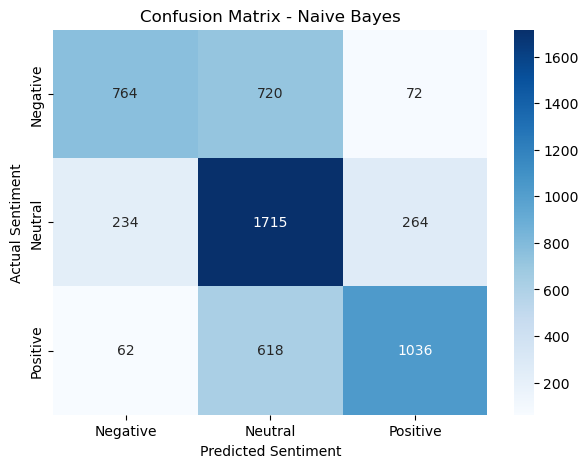

In [46]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

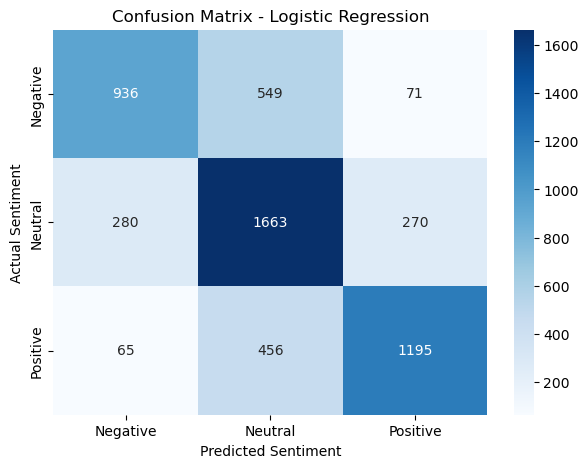

In [47]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

## 8. WordCloud Visualization

WordClouds provide a visual representation of the most frequently occurring words within each sentiment category. Larger words appear more frequently in the corresponding text, making it easier to identify common themes associated with positive, negative, and neutral sentiments.


In [49]:
!pip install wordcloud

In [50]:
from wordcloud import WordCloud

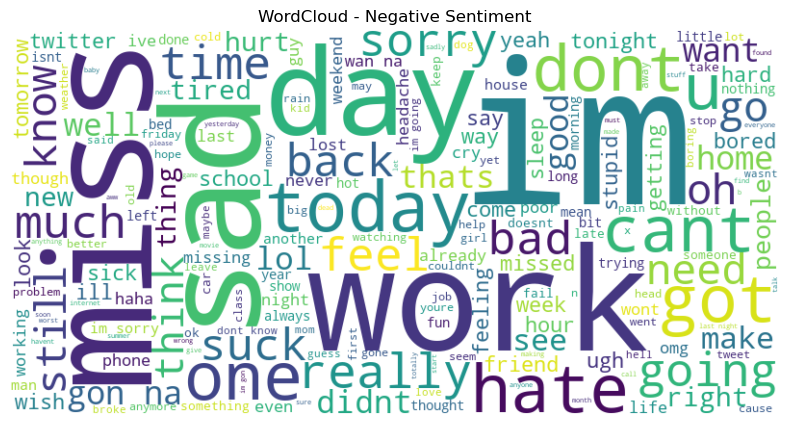

In [51]:
negative_text = " ".join(
    sentiment_df.loc[sentiment_df["sentiment"] == "negative", "cleaned_text"]
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Negative Sentiment")
plt.show()

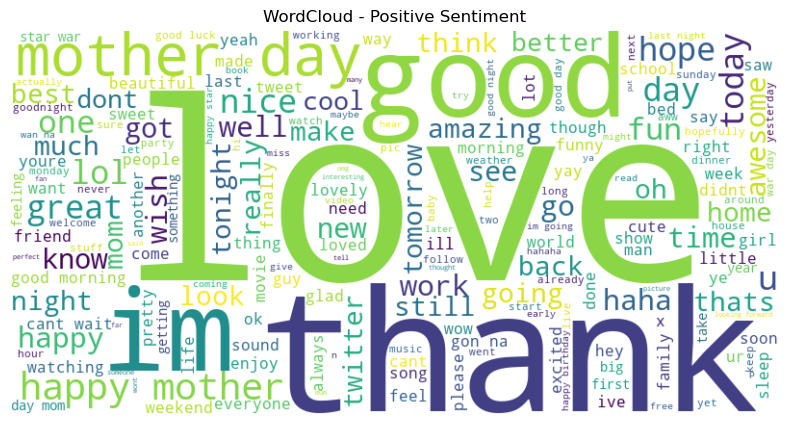

In [52]:
positive_text = " ".join(
    sentiment_df.loc[sentiment_df["sentiment"] == "positive", "cleaned_text"]
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Positive Sentiment")
plt.show()

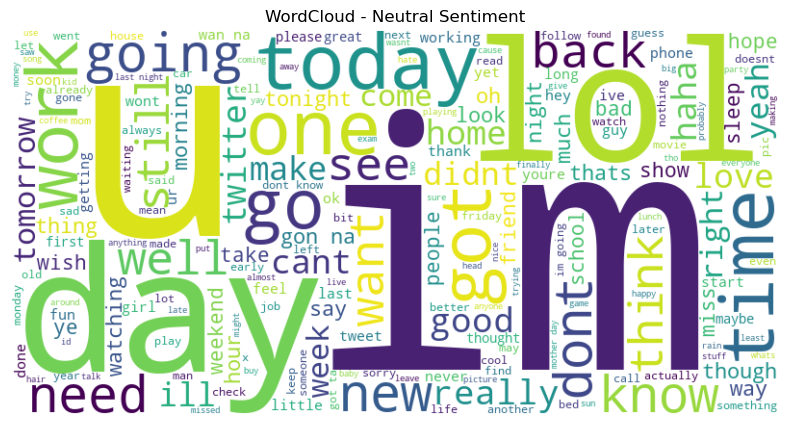

In [62]:
neutral_text = " ".join(
    sentiment_df.loc[sentiment_df["sentiment"] == "neutral", "cleaned_text"]
)

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Neutral Sentiment")
plt.show()

In [54]:
print([var for var in globals() if "pred" in var.lower()])

['y_pred_nb', 'y_pred_lr']


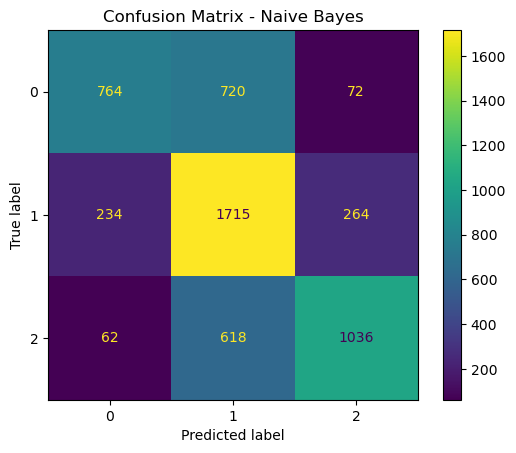

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb
)

disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

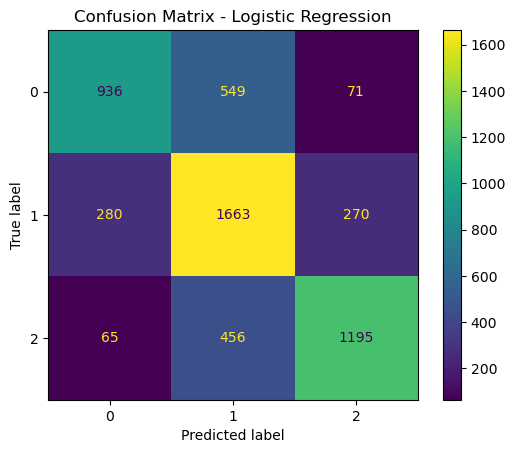

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [57]:
from sklearn.metrics import classification_report

print("Naive Bayes Classification Report")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report
              precision    recall  f1-score   support

    negative       0.72      0.49      0.58      1556
     neutral       0.56      0.77      0.65      2213
    positive       0.76      0.60      0.67      1716

    accuracy                           0.64      5485
   macro avg       0.68      0.62      0.64      5485
weighted avg       0.67      0.64      0.64      5485



In [58]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
              precision    recall  f1-score   support

    negative       0.73      0.60      0.66      1556
     neutral       0.62      0.75      0.68      2213
    positive       0.78      0.70      0.73      1716

    accuracy                           0.69      5485
   macro avg       0.71      0.68      0.69      5485
weighted avg       0.70      0.69      0.69      5485



## 9. Error Analysis

To better understand where the model struggles, we examine five test examples that were misclassified by the Logistic Regression model (the better-performing model). Reviewing these cases helps identify patterns in the types of errors the model makes.

In [63]:
error_df = pd.DataFrame({
    "text": X_test,
    "actual_sentiment": y_test,
    "predicted_sentiment": y_pred_lr
})

misclassified = error_df[error_df["actual_sentiment"] != error_df["predicted_sentiment"]]

misclassified_sample = misclassified.sample(5, random_state=42)
misclassified_sample

,text,actual_sentiment,predicted_sentiment
17541,cheese chip,negative,neutral
16304,starting daya long friday,negative,neutral
15022,course coming boise,negative,neutral
24438,making margarita watch milk good time,positive,neutral
2326,lebron maybe mvp year like lakers win nba title,positive,neutral


### Discussion of Misclassified Examples

Reviewing the misclassified examples above reveals a few common patterns:

- **Short or ambiguous tweets**: Very short texts often lack enough context for the model to confidently determine sentiment.
- **Sarcasm or mixed sentiment**: Tweets containing sarcasm or a mix of positive and negative words within the same sentence can confuse the TF-IDF + Logistic Regression pipeline, since it relies on word frequency rather than deeper context understanding.
- **Neutral vs. negative/positive boundary confusion**: Many errors occur between the "neutral" class and either "positive" or "negative," since neutral tweets can contain emotionally charged individual words without expressing a clear overall sentiment.
- **Preprocessing side effects**: Removing punctuation (like "!!!" or "..." which often signal emphasis or tone) may strip away cues that would otherwise help distinguish sentiment.

These patterns suggest that a model with more contextual understanding (e.g. word embeddings or a transformer-based model) could improve performance on ambiguous or sarcastic examples.

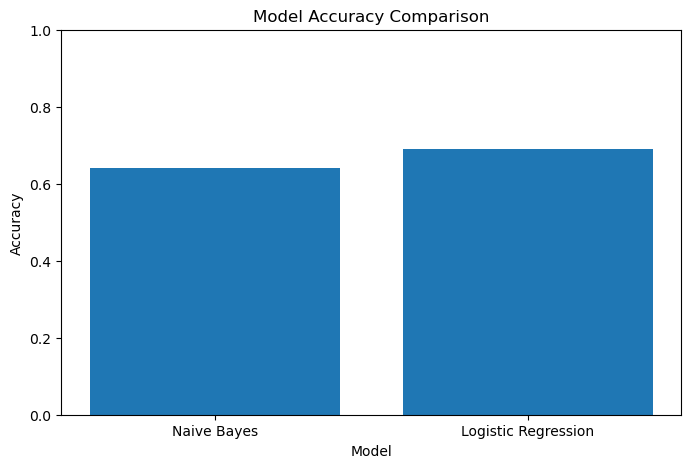

In [59]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression"]
accuracy = [0.64, 0.69]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.show()

In [60]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [0.64, 0.69],
    "Macro Precision": [0.68, 0.71],
    "Macro Recall": [0.62, 0.68],
    "Macro F1-Score": [0.64, 0.69]
})

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,Naive Bayes,0.64,0.68,0.62,0.64
1,Logistic Regression,0.69,0.71,0.68,0.69


## Model Comparison and Analysis

Two machine learning models were evaluated for sentiment classification: Naive Bayes and Logistic Regression.

Logistic Regression achieved the better overall performance, with an accuracy of 69% compared with 64% for Naive Bayes. It also achieved higher macro precision (0.71), macro recall (0.68), and macro F1-score (0.69).

For the individual sentiment classes, Logistic Regression performed particularly well on positive sentiment, achieving a precision of 0.78, recall of 0.70, and F1-score of 0.73. It also improved the classification of negative sentiment compared with Naive Bayes.

Based on these results, Logistic Regression was selected as the better-performing model for this sentiment analysis task.

## Conclusion

In this project, sentiment analysis was performed on textual data using Natural Language Processing and machine learning techniques. The text data was cleaned and preprocessed — including lowercasing, punctuation removal, tokenization, stopword removal, and lemmatization — before being converted into numerical features using TF-IDF and used to train and evaluate sentiment classification models.

Two classification algorithms, Naive Bayes and Logistic Regression, were evaluated using accuracy, precision, recall, and F1-score. Naive Bayes achieved an accuracy of 64%, while Logistic Regression achieved a higher accuracy of 69%, along with better macro precision, recall, and F1-score. Based on these results, **Logistic Regression was selected as the best-performing model** for this sentiment classification task.

The visualizations, including sentiment distribution and word clouds for positive, negative, and neutral sentiment, provided additional insights into the characteristics of the dataset. Confusion matrices and classification reports were used to evaluate the performance of both models in greater detail, showing that most misclassifications occurred between the neutral class and the positive/negative classes, which is expected given how subjective and context-dependent "neutral" tone can be in short text like tweets.

An error analysis of misclassified examples further highlighted common challenges the model faces, including short or ambiguous tweets, sarcasm, mixed sentiment within a single tweet, and the loss of tone-signaling punctuation (e.g. "!!!") during preprocessing. These findings suggest that models with deeper contextual understanding — such as word embeddings or transformer-based architectures (e.g. BERT) — could further improve performance, particularly on the boundary between neutral and emotionally-charged sentiment.

**Real-world applications:** A sentiment classification system like this could be used by businesses to automatically monitor customer feedback and social media mentions, flag negative reviews or complaints for faster response, track public opinion on a product or brand launch over time, or summarize overall customer satisfaction trends without manually reading every review or tweet.

Overall, the project demonstrates how NLP preprocessing, feature extraction, visualization, and machine learning can be combined to build a functional sentiment classification pipeline, while also identifying clear directions for future improvement.